# Feature Engineering and Modelling

1. Import packages
2. Load data
3. Modelling
4. Evaluation
5. Results

## Import packages

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

## Load data

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/drive/MyDrive/Forage/Data Science - BCG /data_for_predictions.csv')
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


In [6]:
print("Shape:", df.shape)
print()
print("Distribusi churn:")
print(df['churn'].value_counts(normalize=True) * 100)

Shape: (14606, 63)

Distribusi churn:
churn
0    90.284814
1     9.715186
Name: proportion, dtype: float64


**Catatan penting:**

dataset ini imbalanced dimana hanya 9.7% pelanggan yang churn. Ini akan memengaruhi bagaimana kita nantinya memilih metrik evaluasi karena akurasi saja bisa menyesatkan pada data imbalanced seperti ini.

## Modelling

We now have a dataset containing features that we have engineered and we are ready to start training a predictive model. Remember, we only need to focus on training a `Random Forest` classifier.

In [7]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

## Data sampling

The first thing we want to do is split our dataset into training and test samples. The reason why we do this, is so that we can simulate a real life situation by generating predictions for our test sample, without showing the predictive model these data points. This gives us the ability to see how well our model is able to generalise to new data, which is critical.

A typical % to dedicate to testing is between 20-30, for this example we will use a 75-25% split between train and test respectively.

In [8]:
# Make a copy of our data
train_df = df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)

(14606, 61)
(14606,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10954, 61)
(10954,)
(3652, 61)
(3652,)


**Catatan:**

Saya menambahkan stratify=y pada *train_test_split* agar proporsi churn (9.7%) tetap konsisten di data train maupun test, penting untuk data yang imbalanced seperti ini, agar test set tetap merepresentasikan distribusi populasi asli.

## Model training

Sekali lagi, dalam contoh ini kita menggunakan klasifikator Random Forest. Random Forest termasuk dalam kategori algoritma ensembel karena secara internal, “Forest” merujuk pada kumpulan Pohon Keputusan yang merupakan algoritma pembelajaran berbasis pohon. Sebagai ilmuwan data, Anda dapat mengontrol seberapa besar “forest” tersebut (artinya, berapa banyak pohon keputusan yang ingin Anda sertakan).

Alasan mengapa algoritma ensemble sangat kuat adalah karena hukum rata-rata, prinsip “weak learners”, dan teorema batas pusat. Jika kita mengambil satu pohon keputusan dan memberinya sampel data serta beberapa parameter, pohon tersebut akan mempelajari pola dari data tersebut. Pohon tersebut mungkin mengalami overfitting atau underfitting, tetapi saat ini itulah satu-satunya harapan kita, yaitu algoritma tunggal tersebut.

Dengan metode ensemble, alih-alih bergantung pada 1 model terlatih saja, kita dapat melatih ribuan pohon keputusan, yang semuanya menggunakan pembagian data yang berbeda dan mempelajari pola yang berbeda pula. Hal ini seperti meminta 1.000 orang untuk belajar cara membuat kode. Hasilnya, Anda akan mendapatkan 1.000 orang dengan jawaban, metode, dan gaya yang berbeda-beda! Konsep “pembelajar lemah” juga berlaku di sini; telah ditemukan bahwa jika Anda melatih pembelajar Anda untuk tidak mengalami overfitting, melainkan mempelajari pola-pola lemah dalam data, dan Anda memiliki banyak pembelajar lemah ini, bersama-sama mereka akan membentuk kumpulan pengetahuan yang sangat prediktif! Ini adalah penerapan nyata dari pepatah “banyak otak lebih baik daripada satu”.

Kini, alih-alih mengandalkan satu pohon keputusan tunggal untuk prediksi, Random Forest menggabungkannya dengan pandangan keseluruhan dari seluruh kolom.

In [10]:
model = RandomForestClassifier(
    n_estimators=1000,       # jumlah pohon keputusan dalam forest
    random_state=42,         # agar hasil dapat direproduksi
    class_weight='balanced', # memberi bobot lebih pada kelas minoritas (churn) karena data imbalanced
    n_jobs=-1                # gunakan semua core untuk mempercepat training
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=1000, n_jobs=-1,
                       random_state=42)

**Penjelasan pilihan parameter:**

* `n_estimators=1000`: jumlah pohon yang cukup besar agar hasil prediksi stabil (voting dari lebih banyak "weak learners"), sambil tetap dalam batas waktu komputasi yang wajar.
* `class_weight='balanced'`: karena hanya 9.7% pelanggan yang churn, tanpa penyesuaian ini model cenderung "malas" memprediksi churn (kelas minoritas) karena akurasi tinggi tetap tercapai hanya dengan menebak "tidak churn" untuk semua orang. Parameter ini memberi bobot lebih besar pada kesalahan di kelas minoritas saat training.
* `random_state=42`: memastikan hasil dapat direproduksi ulang.

## Evaluation

Now let's evaluate how well this trained model is able to predict the values of the test dataset.

In [11]:
# Generate predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

## Kenapa saya memilih metrik evaluasi ini?

Karena **churn rate hanya ~9.7%** (data sangat imbalanced), accuracy saja tidak cukup dan bisa menyesatkan: model yang selalu memprediksi "tidak churn" untuk semua pelanggan akan tetap mendapat akurasi ~90%, padahal model itu sama sekali tidak berguna untuk tujuan bisnis (mengidentifikasi siapa yang akan churn).

Oleh karena itu saya menggunakan kombinasi metrik berikut:

* **Confusion matrix**: untuk melihat secara eksplisit berapa banyak true positive (churn yang berhasil ditangkap), false negative (churn yang terlewat — paling mahal secara bisnis karena **PowerCo** kehilangan pelanggan tanpa sempat melakukan intervensi retensi), dan false positive (pelanggan yang diprediksi churn padahal tidak — biayanya hanya berupa penawaran retensi yang "terbuang").
* **Precision**: dari semua pelanggan yang diprediksi churn, berapa persen yang benar-benar churn? Penting agar tim retensi tidak membuang sumber daya (diskon, penawaran khusus) ke pelanggan yang sebenarnya tidak akan churn.
* **Recall (sensitivity)**: dari semua pelanggan yang benar-benar churn, berapa persen yang berhasil terdeteksi model? Ini metrik paling penting dalam kasus bisnis ini, karena tujuan utama **PowerCo** adalah menangkap sebanyak mungkin pelanggan berisiko churn agar bisa dilakukan intervensi sebelum mereka benar-benar pergi.
* **F1-score**: rata-rata harmonik precision & recall, berguna sebagai ringkasan tunggal saat kita perlu menyeimbangkan keduanya.
* **ROC-AUC**: mengukur kemampuan model membedakan kelas churn vs tidak churn di seluruh ambang batas (threshold) probabilitas, tidak bergantung pada satu titik potong tertentu. Berguna untuk menilai kualitas ranking prediksi model secara keseluruhan, terutama karena data imbalanced.

Saya tidak menjadikan accuracy sebagai metrik utama justru karena sifatnya yang menyesatkan pada kasus imbalanced seperti ini walaupun begitu tetap saya tampilkan sebagai referensi.

=== Confusion Matrix ===
[[3283    3]
 [ 346   20]]



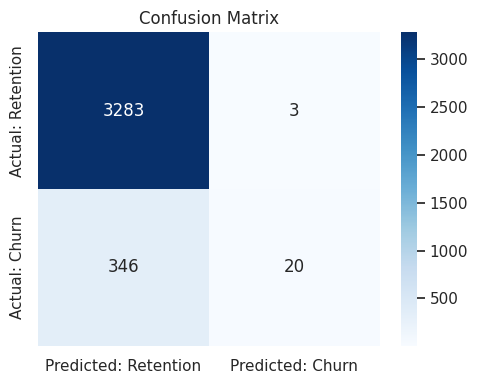

In [15]:
print("=== Confusion Matrix ===")
cm = metrics.confusion_matrix(y_test, y_pred)
print(cm)
print()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Retention', 'Predicted: Churn'],
            yticklabels=['Actual: Retention', 'Actual: Churn'], ax=ax)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [16]:
print("=== Classification Report ===")
print(metrics.classification_report(y_test, y_pred, target_names=['Retention', 'Churn']))

print("Accuracy  :", round(metrics.accuracy_score(y_test, y_pred), 4))
print("Precision :", round(metrics.precision_score(y_test, y_pred), 4))
print("Recall    :", round(metrics.recall_score(y_test, y_pred), 4))
print("F1-score  :", round(metrics.f1_score(y_test, y_pred), 4))
print("ROC-AUC   :", round(metrics.roc_auc_score(y_test, y_pred_proba), 4))

=== Classification Report ===
              precision    recall  f1-score   support

   Retention       0.90      1.00      0.95      3286
       Churn       0.87      0.05      0.10       366

    accuracy                           0.90      3652
   macro avg       0.89      0.53      0.53      3652
weighted avg       0.90      0.90      0.86      3652

Accuracy  : 0.9044
Precision : 0.8696
Recall    : 0.0546
F1-score  : 0.1028
ROC-AUC   : 0.6611


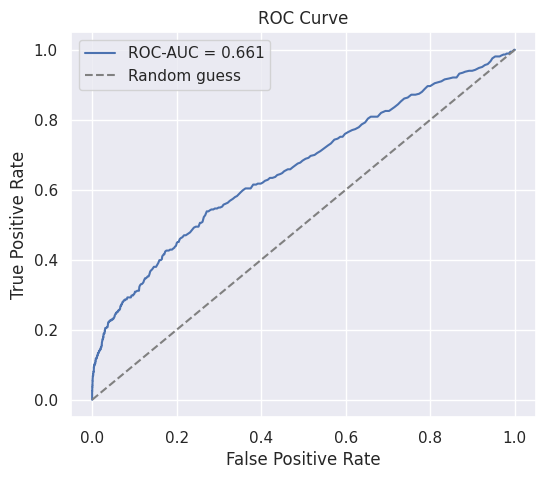

In [17]:
# ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {metrics.roc_auc_score(y_test, y_pred_proba):.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Baseline pembanding

Untuk memberi konteks apakah performa model ini benar-benar berguna, kita bandingkan **basleine naif**: model yang selalu mempredisksi "tidak churn' untuk semua pelanggan

In [18]:
baseline_pred = np.zeros(len(y_test))
print("Baseline (selalu prediksi 'tidak churn'):")
print("Accuracy :", round(metrics.accuracy_score(y_test, baseline_pred), 4))
print("Recall   :", round(metrics.recall_score(y_test, baseline_pred), 4), " <- tidak menangkap churn sama sekali!")

Baseline (selalu prediksi 'tidak churn'):
Accuracy : 0.8998
Recall   : 0.0  <- tidak menangkap churn sama sekali!


## Feature importance



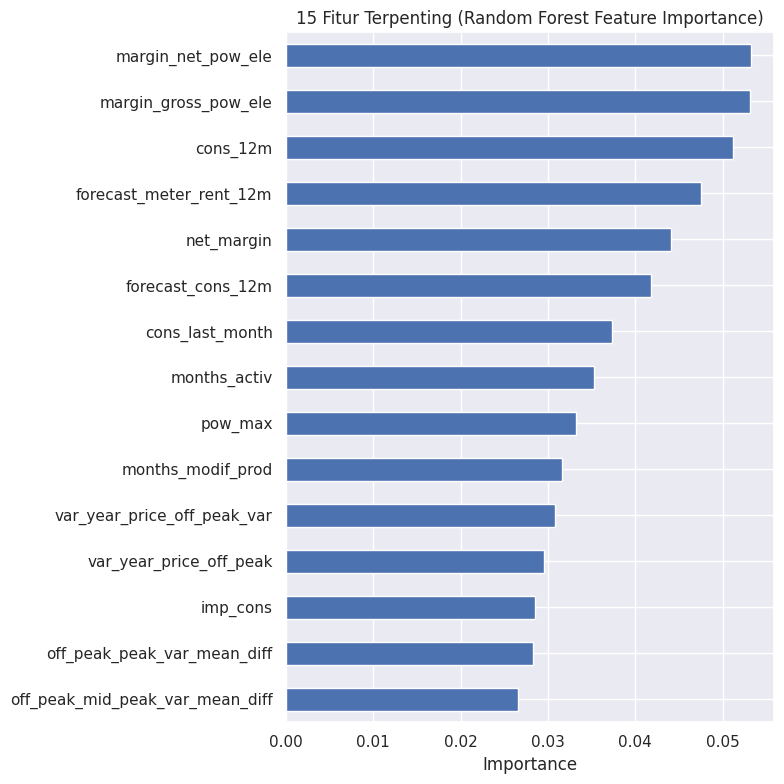

,0
margin_net_pow_ele,0.053211
margin_gross_pow_ele,0.053142
cons_12m,0.051213
forecast_meter_rent_12m,0.047466
net_margin,0.044121
forecast_cons_12m,0.041819
cons_last_month,0.037285
months_activ,0.035215
pow_max,0.033236
months_modif_prod,0.031622


In [19]:
importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
importances.head(15).sort_values().plot(kind='barh', ax=ax)
plt.title('15 Fitur Terpenting (Random Forest Feature Importance)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances.head(15)

**Insight:**

Perhatian apakah fitur turunan harga (`offpeak_diff_dec_january_energy`,`offpeak_diff_dec_january_power`, dan fitur volatilitas harga lain) muncul di jajaran atas. Jika ya, ini mendukung hipotesis Estelle bahwa selisih harga off-peak Desember-Januari relevan. Tapi, jika fitur seperti `net_margin`, `tenure/months_active` atau `forecast_meter_rent_12m` justru lebih dominan, ini memperkuat temuan EDA sebelumnya bahwa **harga bukan satu-satunya, atau bahkan bukan faktor utama**. Faktor seperti tenure, margin, dan pola konsumsi tampaknya berperan lebih besar,


# Secara keseluruhan, apakah model ini memuaskan?

Hasil aktual pada test set:

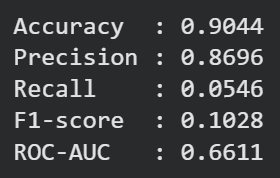

**Jawabannya adalah belum memuaskan untuk penggunaan operasional, meskipun modelnya bukan tanpa nilai sama sekali**

Alasannya:
1. **Recall hanya 5.4%** yang artinya dari semua pelanggan yang benar-benar churn, model ini hanya berhasil menangkap sekitar 1 dari 18 orang. Sebanyak ~94.5% pelanggan yang akan churn justru lolos tanpa terdeteksi (false negative). Untuk tujuan bisnis PowerCo yaitu mengidentifikasi pelanggan berisiko agar bisa dilakukan intervensi retensi, ini adalah kelemahan besar karena hampir seluruh kasus yang justru ingin kita tangkap malah terlewat.
2. **Precision cukup tinggi (87.0%)** yg artinya ketika model memang memprediksi seseorang akan churn, prediksi itu kemungkinan besar benar. Tapi ini hanya berguna jika modelnya juga menangkap cukup banyak kasus churn — dan di sinilah recall yang sangat rendah menjadi masalah utama: model ini pada dasarnya "sangat berhati-hati" dan hanya berani memprediksi churn pada kasus yang paling jelas sekalipun, sehingga melewatkan mayoritas kasus yang lebih ambigu.
3. **Accuracy 90.4% terlihat tinggi**, tapi ini menyesatkan: baseline naif yang selalu menebak "tidak churn" saja sudah mencapai akurasi ~90.3% tanpa mendeteksi satupun churn. Artinya model kita nyaris tidak menambah nilai dibanding baseline itu dari sisi akurasi — inilah alasan utama saya menekankan pentingnya melihat recall/precision/ROC-AUC, bukan accuracy, sejak bagian metrik evaluasi di atas.
4. **ROC-AUC 0.661** menunjukkan model punya sedikit kemampuan membedakan churn vs non-churn di atas tebakan acak (0.5), tapi ini tergolong lemah — jauh dari kuat (idealnya mendekati 0.8-0.9+ untuk model yang benar-benar andal secara bisnis). Bersama recall yang sangat rendah, ini menunjukkan model kesulitan memisahkan pola churn dari data yang tersedia saat ini.

Secara keseluruhan: model ini **sedikit lebih baik daripada menebak secara random**, tetapi **recall yang sangat rendah dan ROC-AUC yang lemah membuatnya belum layak dipakai sebagai dasar keputusan bisnis** (misalnya untuk menentukan siapa yang akan diberi penawaran retensi), karena akan melewatkan hampir semua pelanggan yang sebenarnya berisiko churn.

**Rekomendasi langkah selanjutnya untuk memperbaiki recall:**
* **Menurunkan threshold klasifikasi** dari default 0.5 (misalnya ke 0.2–0.3) — karena model menghasilkan probability score, bukan hanya label 0/1, kita bisa menggeser titik potong untuk menangkap lebih banyak churn dengan trade-off precision yang lebih rendah (perlu dihitung ulang berapa nilai bisnis satu pelanggan yang hilang vs biaya satu penawaran retensi yang salah sasaran).
* **Hyperparameter tuning** (`max_depth`, `min_samples_leaf`, `n_estimators`, `class_weight`) via GridSearch/RandomizedSearch dengan cross-validation, karena `class_weight='balanced'` saja ternyata belum cukup mengatasi imbalance pada kasus ini.
* **Teknik resampling seperti SMOTE (oversampling kelas minoritas)** atau undersampling kelas mayoritas pada data training.
* Mencoba algoritma lain sebagai pembanding (Gradient Boosting/XGBoost, Logistic Regression dengan class weighting) dan melakukan ensembling.
* Menambah fitur eksternal (kompetitor, kepuasan layanan pelanggan) yang sempat direkomendasikan pada tahap pengumpulan data di awal kasus — kemungkinan fitur yang ada saat ini memang belum cukup kaya untuk menangkap sinyal churn secara akurat.

**Kesimpulan terhadap hipotesis awal klien:** dilihat dari daftar feature importance di atas, fitur-fitur turunan harga (offpeak_diff_dec_january_energy/power, volatilitas harga) **tidak mendominasi** daftar fitur terpenting — fitur seperti margin, tenure, dan konsumsi tampak lebih berpengaruh. **Ini membantah anggapan awal PowerCo bahwa sensitivitas harga adalah pendorong utama churn**, dan mengarahkan rekomendasi strategis PowerCo untuk lebih fokus pada faktor non-harga (kualitas layanan, pengalaman pelanggan, channel akuisisi) — sambil tetap memperbaiki model (lihat rekomendasi di atas) sebelum layak dipakai secara operasional.